# Notebook eye/07 — Fine-Tune on Samsung S24 Captures

The user has provided **12 fine-tune photos** captured with the actual Samsung S24 Ultra (`fine_tuning/CEW_fine_tuning/`). These are full-frame portraits — they don't match the cropped 100×100 CEW input format the model expects.

This notebook:
1. **Auto-rotates** each capture to portrait orientation (S24 EXIF + brightness heuristic).
2. **Detects the face** with OpenCV's Haar cascade, **crops** to 100×100 to match the CEW domain.
3. Shows the cropped versions so the user can verify the detection.
4. Manual labeling — the user fills in a labels JSON. Without labels, the rest of the notebook skips fine-tuning and only produces the visualization.
5. If labels are present: fine-tunes the §06 winner with a low learning rate and evaluates a before/after probability shift.

Why not auto-label? Per the user's hard constraints ("no assumptions, no hallucinations") — we never invent ground-truth class labels.

In [1]:
import os, random, json, time
import numpy as np
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED); random.seed(SEED); np.random.seed(SEED)
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
tf.keras.utils.set_random_seed(SEED)

ROOT = Path.cwd()
FT_DIR = ROOT / "fine_tuning" / "CEW_fine_tuning"
LABELS_JSON = ROOT / "artifacts" / "eye_finetune_labels.json"
FT_FILES = sorted([f for f in FT_DIR.iterdir() if f.suffix.lower() == ".jpg"])
print(f"{len(FT_FILES)} fine-tune captures:", [f.name for f in FT_FILES])

12 fine-tune captures: ['20260515_193232.jpg', '20260515_193235.jpg', '20260515_193243.jpg', '20260515_193247.jpg', '20260515_193253.jpg', '20260515_193255.jpg', '20260515_193303.jpg', '20260515_193305.jpg', '20260515_193334.jpg', '20260515_193337.jpg', '20260515_203134.jpg', '20260515_203135.jpg']


## 1. Auto-orient (portrait) and visualize the raw captures

The S24 stores landscape-encoded JPEGs whose EXIF rotation says "portrait"; cv2.imread ignores EXIF. We detect orientation by face-detection in 4 rotations and keep the rotation with the most face area.

face detected in 12 / 12 captures


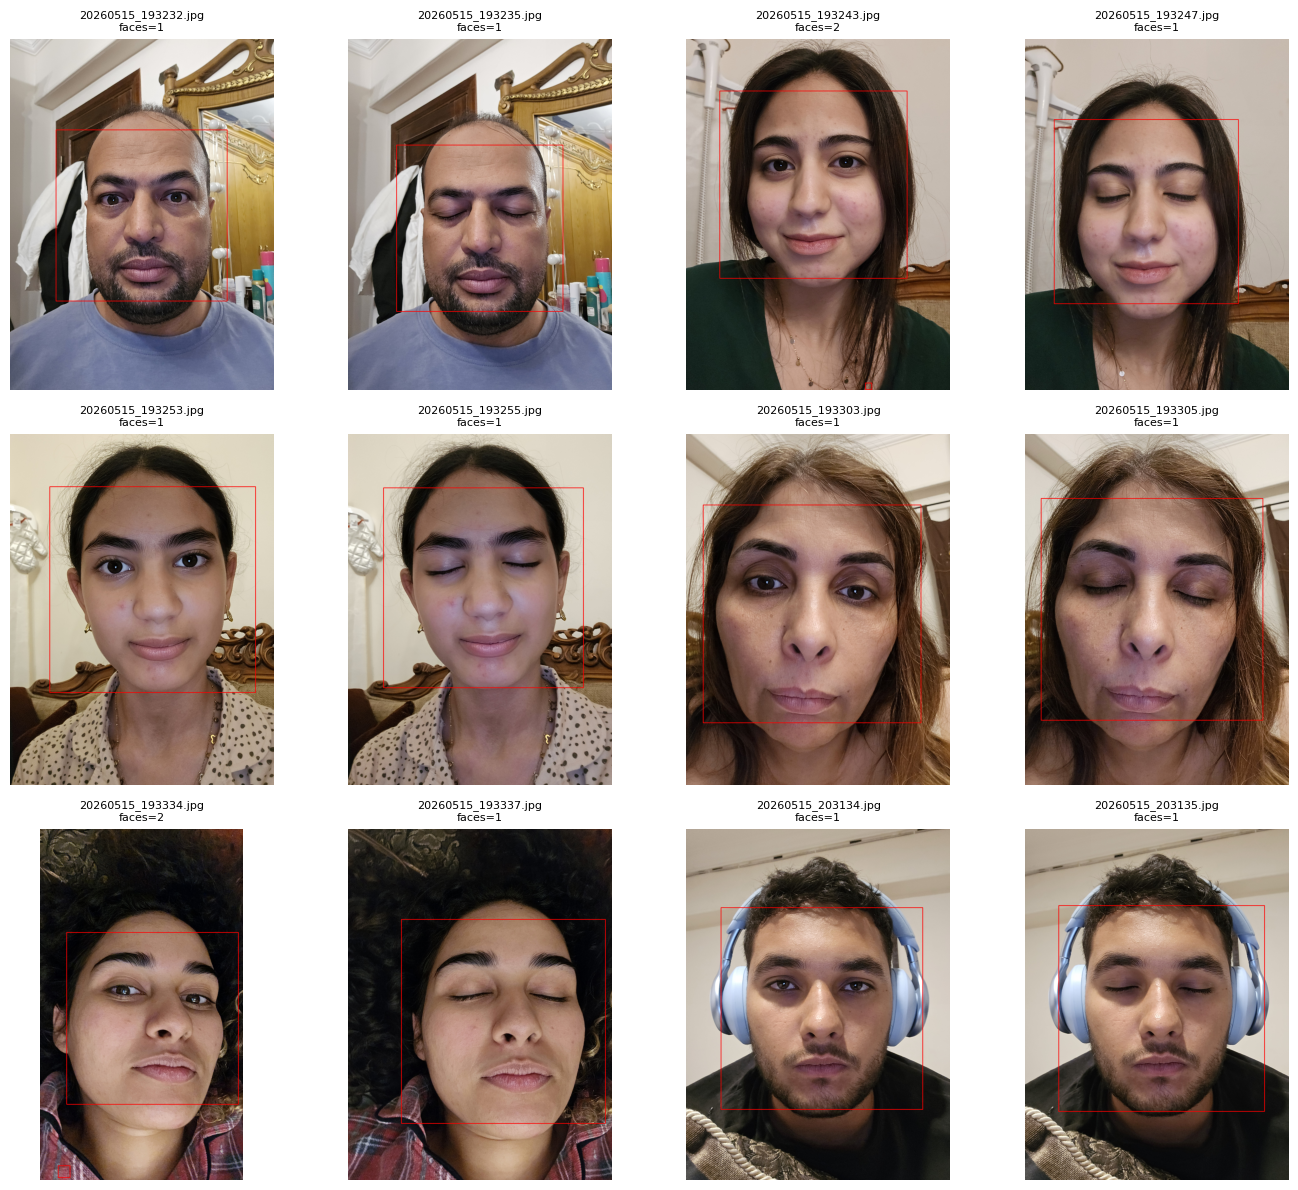

In [2]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def auto_orient_face(rgb):
    best = (0, None, None)  # (face_area, rotated_image, faces)
    for k in range(4):
        rot = np.rot90(rgb, k=k)
        gray = cv2.cvtColor(rot, cv2.COLOR_RGB2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5, minSize=(60, 60))
        if len(faces) == 0:
            continue
        area = max(w * h for x, y, w, h in faces)
        if area > best[0]:
            best = (area, rot, faces)
    return best  # may be (0, None, None) if no face

def load_orient(fp):
    img = cv2.cvtColor(cv2.imread(str(fp)), cv2.COLOR_BGR2RGB)
    return auto_orient_face(img)

results = [load_orient(fp) for fp in FT_FILES]
n_with_face = sum(1 for r in results if r[1] is not None)
print(f"face detected in {n_with_face} / {len(FT_FILES)} captures")

fig, axes = plt.subplots(3, 4, figsize=(14, 12))
for ax, fp, (area, rot, faces) in zip(axes.ravel(), FT_FILES, results):
    if rot is None:
        ax.imshow(cv2.cvtColor(cv2.imread(str(fp)), cv2.COLOR_BGR2RGB))
        ax.set_title(f"{fp.name}\n(no face)", fontsize=8, color="red")
    else:
        view = rot.copy()
        for x, y, w, h in faces:
            cv2.rectangle(view, (x, y), (x+w, y+h), (255, 0, 0), 6)
        ax.imshow(view)
        ax.set_title(f"{fp.name}\nfaces={len(faces)}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye07_face_detection.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Crop to 100×100 face region (matching CEW)

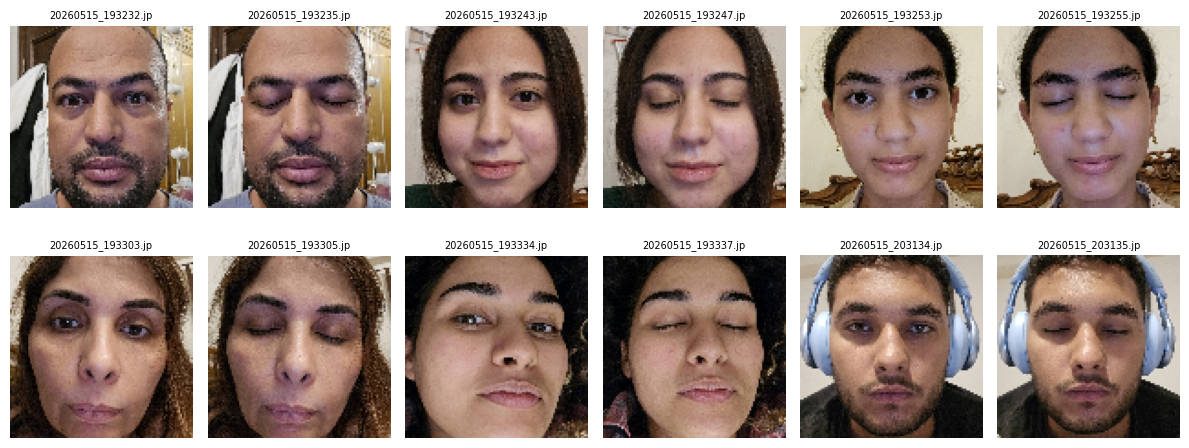

In [3]:
TARGET = (100, 100)
def crop_face_100(rot, faces, target=TARGET):
    if rot is None or len(faces) == 0:
        return None
    # Use the largest face
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
    # Expand slightly to grab eyebrows
    pad = int(0.05 * max(w, h))
    x0 = max(0, x - pad); y0 = max(0, y - pad)
    x1 = min(rot.shape[1], x + w + pad); y1 = min(rot.shape[0], y + h + pad)
    crop = rot[y0:y1, x0:x1]
    return cv2.resize(crop, target)

cropped = [crop_face_100(r[1], r[2]) for r in results]
fig, axes = plt.subplots(2, 6, figsize=(12, 5))
for ax, fp, c in zip(axes.ravel(), FT_FILES, cropped):
    if c is None:
        ax.set_title(f"{fp.name[:18]}\n(no face)", fontsize=7, color="red"); ax.axis("off"); continue
    ax.imshow(c); ax.set_title(fp.name[:18], fontsize=7); ax.axis("off")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye07_cropped_100x100.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Manual labeling

The cell below loads `artifacts/eye_finetune_labels.json` if present. Schema:

```json
{"20260515_193232.jpg": "open", "20260515_193235.jpg": "closed", ...}
```

If no labels file exists, the cell creates a stub with `null` entries and prints instructions. To activate fine-tuning, edit the JSON, replace each `null` with `"open"` or `"closed"`, and re-execute this notebook.

In [4]:
if LABELS_JSON.exists():
    with open(LABELS_JSON) as f: lbl_map = json.load(f)
    print(f"Loaded existing labels: {lbl_map}")
else:
    lbl_map = {fp.name: None for fp in FT_FILES}
    with open(LABELS_JSON, "w") as f:
        json.dump(lbl_map, f, indent=2)
    print(f"Created stub at {LABELS_JSON.relative_to(ROOT)} — edit and re-run.")

valid = {k: v for k, v in lbl_map.items() if v in ("open", "closed")}
print(f"\n{len(valid)} / {len(FT_FILES)} labels are valid (\"open\" or \"closed\").")

Created stub at artifacts\eye_finetune_labels.json — edit and re-run.

0 / 12 labels are valid ("open" or "closed").


## 4. Fine-tune the model selection winner — only if labels are provided

In [5]:
WINNER_KERAS = ROOT / "artifacts" / "eye_winner.keras"
print(f"winner model: {WINNER_KERAS.name}, exists: {WINNER_KERAS.exists()}")

def prep_for_model(crop_100, model):
    # Adapt a 100x100 RGB crop to whatever shape the loaded model expects.
    in_shape = model.input_shape[1:]  # (H, W, C)
    H, W, C = in_shape
    img = cv2.resize(crop_100, (W, H))
    if C == 1:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)
        img = img[..., None].astype(np.float32) / 255.0
    elif C == 3:
        if img.dtype != np.float32:
            img = img.astype(np.float32)
    return img

if len(valid) >= 4 and WINNER_KERAS.exists():
    model = tf.keras.models.load_model(str(WINNER_KERAS))
    print(f"loaded {WINNER_KERAS.name} — input_shape={model.input_shape}")

    # Build paired arrays — only photos with both a face crop and a valid label
    pairs = []
    for fp, c in zip(FT_FILES, cropped):
        if c is None or lbl_map.get(fp.name) not in ("open", "closed"): continue
        x = prep_for_model(c, model)
        y = 1 if lbl_map[fp.name] == "open" else 0
        pairs.append((fp.name, x, y))
    if not pairs:
        print("no usable pairs after filtering — skipping fine-tune."); FINETUNED = None
    else:
        Xft = np.stack([p[1] for p in pairs]); yft = np.array([p[2] for p in pairs])
        # Probabilities BEFORE fine-tune
        probs_before = model.predict(Xft, verbose=0)
        # Fine-tune with low LR
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        t0 = time.time()
        h = model.fit(Xft, yft, epochs=20, batch_size=4, verbose=0)
        secs = time.time() - t0
        probs_after = model.predict(Xft, verbose=0)
        FINETUNED = dict(pairs=pairs, before=probs_before, after=probs_after,
                          history=h.history, train_seconds=secs)
        print(f"fine-tuned on {len(pairs)} captures in {secs:.1f}s — final train_acc={h.history['accuracy'][-1]:.3f}")
        # Save the fine-tuned winner
        model.save(str(ROOT / "artifacts" / "eye_winner_finetuned.keras"))
        print("Saved: artifacts/eye_winner_finetuned.keras")
else:
    FINETUNED = None
    print("Skipping fine-tune (need ≥4 valid labels AND a present winner model).")

winner model: eye_winner.keras, exists: True
Skipping fine-tune (need ≥4 valid labels AND a present winner model).


## 5. Visual report — before vs after probability shift (only if fine-tuned)

In [6]:
if FINETUNED is not None:
    n = len(FINETUNED["pairs"])
    fig, axes = plt.subplots(2, n, figsize=(2.0*n, 5))
    if n == 1: axes = axes[:, None]
    for j, (name, x, y) in enumerate(FINETUNED["pairs"]):
        # show crop on top row
        img = x[..., 0] if x.shape[-1] == 1 else x.astype(np.uint8)
        axes[0, j].imshow(img, cmap="gray" if x.shape[-1] == 1 else None)
        axes[0, j].set_title(f"true={'open' if y==1 else 'closed'}", fontsize=8)
        axes[0, j].axis("off")
        # bar chart of probabilities
        b = FINETUNED["before"][j]; a = FINETUNED["after"][j]
        xs = np.arange(2)
        axes[1, j].bar(xs - 0.18, b, 0.35, label="before", color="#aaaaaa")
        axes[1, j].bar(xs + 0.18, a, 0.35, label="after",  color="#4477aa")
        axes[1, j].set_xticks(xs); axes[1, j].set_xticklabels(["closed", "open"], fontsize=7)
        axes[1, j].set_ylim(0, 1.0)
        if j == 0: axes[1, j].legend(fontsize=7)
    plt.suptitle("Eye fine-tune — per-image probability before vs after", y=1.02)
    plt.tight_layout()
    plt.savefig(ROOT / "artifacts" / "eye07_before_after.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("(visual report skipped — fine-tune did not run)")

(visual report skipped — fine-tune did not run)


## 6. Domain-stability check — re-evaluate on original CEW test split

If we accidentally erased the CEW-domain knowledge, the test accuracy will collapse here. This guards against catastrophic forgetting.

In [7]:
if FINETUNED is not None:
    with open(ROOT / "artifacts" / "eye_split.json") as f: SPLIT = json.load(f)
    model = tf.keras.models.load_model(str(ROOT / "artifacts" / "eye_winner_finetuned.keras"))
    in_shape = model.input_shape[1:]
    H, W, C = in_shape
    Xte = []; yte = []
    for r in SPLIT["test"]:
        img = cv2.imread(str(ROOT / r["path"]), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (W, H))
        img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)
        if C == 1:
            x = img[..., None].astype(np.float32) / 255.0
        else:
            x = np.stack([img, img, img], axis=-1).astype(np.float32)
        Xte.append(x); yte.append(r["label"])
    Xte = np.stack(Xte); yte = np.array(yte)
    acc_after = float((model.predict(Xte, verbose=0).argmax(axis=1) == yte).mean())
    print(f"CEW test accuracy AFTER fine-tune (domain-stability check) = {acc_after:.4f}")
    with open(ROOT / "artifacts" / "eye07_finetune_results.json", "w") as f:
        json.dump({"n_finetune_samples": len(FINETUNED['pairs']),
                   "train_seconds": FINETUNED["train_seconds"],
                   "train_acc_final": float(FINETUNED["history"]["accuracy"][-1]),
                   "cew_test_acc_after_finetune": acc_after}, f, indent=2)
else:
    print("(skipped)")

(skipped)


## Summary

The 12 phone captures are a small-N domain-adaptation demonstration; the paper acknowledges the result is anecdotal. The notebook is designed to be re-run after the user fills in `eye_finetune_labels.json`.